In [1]:
%%HTML
<!-- Mejorar visualización en proyector -->
<style>
.rendered_html {font-size: 1.2em; line-height: 150%;}
div.prompt {min-width: 0ex; padding: 0px;}
.container {width:95% !important;}
</style>

In [2]:
# Tarea: Taxi

#En grupos de tres estudiantes resuelvan el ambiente ["Taxi-v3"](https://gym.openai.com/envs/Taxi-v3/)


#- Describa detalladamente el ambiente (estados posibles, acciones posibles, recompensas, etc)
#- Utilice $\epsilon$ greedy Q-learning para entrenar un agente que resuelva el problema
#- Muestre en una gráfica la evolución de la recompensa promedio de su agente
#Describa el algoritmo de ϵ
#greedy Q-learning y sus parámetros
#Utilice ϵ greedy Q-learning para entrenar un agente que resuelva el problema, indique la mejor configuración de parámetros que encontró para este problema
#Muestre la tabla Q, escoja 4 estados y razone sobre los resultados obtenidos
#Muestre en una gráfica la evolución de la recompensa promedio de su agente y el número de pasos promedios
#Grabe un video o una animación de su agente ejecutando la tarea 5 veces

from IPython.display import clear_output
from time import sleep

import gymnasium as gym
import cv2

import matplotlib.pyplot as plt
%matplotlib inline
 
env = gym.make("Taxi-v3", render_mode="rgb_array")

# obtener dimensiones del frame
obs, info = env.reset()
frame = env.render()
h, w, _ = frame.shape
print("Información inicial de librería taxi para proceso de grabación\n")
print(f'Información inicial {info}, \nobs: {obs}')
print(f'Alto {h}, \nAncho: {w}')

/media/diego/Cofre/miniconda3/envs/taxi/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Información inicial de librería taxi para proceso de grabación

Información inicial {'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)}, 
obs: 141
Alto 350, 
Ancho: 550


# Descripción

   **Descripción:**
    Hay cuatro lugares designados en la grilla indicados por (R, G, Y y B). Cuando el episodio comienzsa, el taxi comienza desde una esquina aleatoria y el pasajero está en otro cuadro aleatorio. El taxi conduce hacia la ubicación del pasajero, lo toma y conduce hacia el destino del pasajero (alguna otra de las cuatro esquinas) y luego lo deja. Una vez que deja al pasajero, el episodio termina.


### Descripción de Ambiente

**Observaciones:**
   Hay un espacio discreto de 500 estados; 
   ## ya que hay 25 posiciones para el taxi.
   
   ### 5 posibles ubicaciones del pasajero (incluyendo el caso cuando el pasajero está en el Taxi):
   - 0: R (red -> rojo)
   - 1: G (green -> verde)
   - 2: Y (yellow -> amarillo)
   - 3: B (blue -> azul)
   - 4: En taxi
   ### 4 destinos:
   - 0: R (red -> rojo)
   - 1: G (green -> verde)
   - 2: Y (yellow -> amarillo)
   - 3: B (blue -> azul)
   

##### R: Estados posibles 500

In [3]:
# Espacio de estados
display(env.observation_space)
display(env.observation_space.n)

Discrete(500)

500

##### R Acciones posee 6 acciones deterministas
 **Acciones:**
    Hay 6 acciones deterministicas:
   - 0: mover al Sur
   - 1: mover al norte
   - 2: mover al Este
   - 3: mover al Oeste
   - 4: Tomar pasajero
   - 5: Dejar pasajero

In [4]:
# Espacio de acciones
display(env.action_space)
display(env.action_space.n)

Discrete(6)

6

##### R Recompensas de cada acción:
       * -1 por cada acción, +20 por cada pasajero en viaje
       *-10 por acciones de subir y bajar ilegalmente.

In [5]:
print(f'Tipo de dato {type(env)}')
print(f'+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
print(f'Libreria de accesos {dir(env)}')

Tipo de dato <class 'gymnasium.wrappers.common.TimeLimit'>
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Libreria de accesos ['__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_action_space', '_cached_spec', '_elapsed_steps', '_is_protocol', '_max_episode_steps', '_metadata', '_np_random', '_np_random_seed', '_observation_space', '_saved_kwargs', 'action_space', 'class_name', 'close', 'env', 'get_wrapper_attr', 'has_wrapper_attr', 'metadata', 'np_random', 'np_random_seed', 'observation_space', 'render', 'render_mode', 'reset', 'set_wrapper_attr', 'spec', 'step', 'unwrapp

In [6]:
paradero={0:'Sur',1:'Norte',2:'Este',3:'Oeste',4:'Recoge',5:'Desciende'}
display(f'Cantidad de estados {len(env.unwrapped.P)}')
for a in range(0,len(env.unwrapped.P[250])):
    for b in env.unwrapped.P[250][a]:
        display(f'Parada {paradero[a]}, Probabilidad {b[0]}, Donde Vá {b[1]}, Recompensa {b[2]}, Pasajero I/O {b[3]}')
#display(f'Despliege de estado 250: {env.unwrapped.P[250]}')

'Cantidad de estados 500'

'Parada Sur, Probabilidad 1.0, Donde Vá 350, Recompensa -1, Pasajero I/O False'

'Parada Norte, Probabilidad 1.0, Donde Vá 150, Recompensa -1, Pasajero I/O False'

'Parada Este, Probabilidad 1.0, Donde Vá 270, Recompensa -1, Pasajero I/O False'

'Parada Oeste, Probabilidad 1.0, Donde Vá 230, Recompensa -1, Pasajero I/O False'

'Parada Recoge, Probabilidad 1.0, Donde Vá 250, Recompensa -10, Pasajero I/O False'

'Parada Desciende, Probabilidad 1.0, Donde Vá 250, Recompensa -10, Pasajero I/O False'

# Calcula la cantidad de acciones aleatorios que produce en 100 estados 

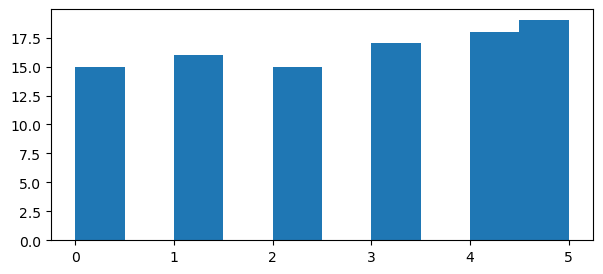

In [7]:
import numpy as np
a = []
for i in range(100):
    a.append(env.action_space.sample())

plt.figure(figsize=(7, 3))
plt.hist(np.array(a));

## Demostración de uso de librería con exportación multimedia

In [8]:
#Gráficas de despliegue
def show_tables(arrival_state, rewards):
    fig, axes = plt.subplots(1, 2,figsize=(10, 4), layout='constrained')
    axes[0].set_title("Llegadas")
    axes[0].set_xlabel("Estados")
    axes[0].set_ylabel("Cantidad Acumulada")
    axes[0].hist(np.array(arrival_state))
    
    axes[1].set_title("Recompensas")
    axes[1].set_xlabel("Valor")
    axes[1].set_ylabel("Cantidad")
    axes[1].hist(np.array(rewards))
    plt.show()

Video guardado en ./video/eval01.mp4
Estados visitados: [326, 164, 28, 81, 442]
Recompensas: [-1, -10, -10, -10, -1]


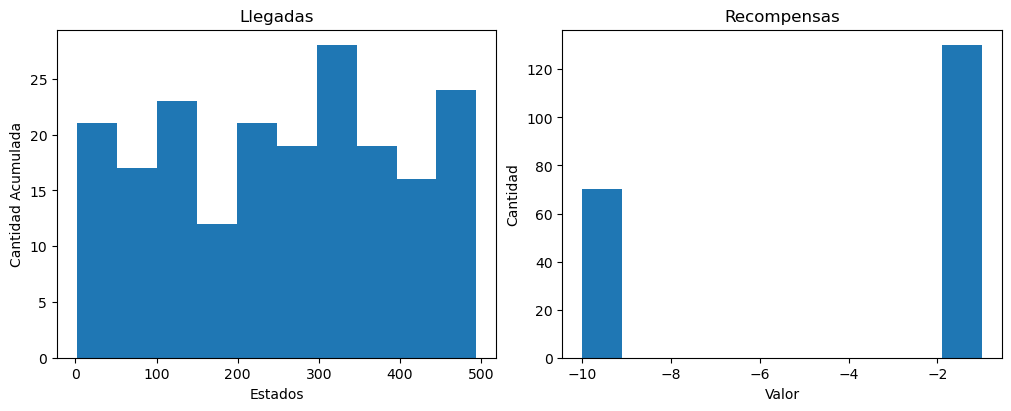

In [9]:
#Algoritmo de Taxi con propiedad de grabación multimedia por paso
#Renderización usando rgb_array
env = gym.make("Taxi-v3", render_mode="rgb_array") 

# obtener dimensiones del frame
obs, info = env.reset()
frame = env.render()

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("./video/eval01.mp4", fourcc, 4, (w, h))  # 4 fps para taxi

arrival_state = []
rewards = []
try:
    for k in range(200):
        obs, info = env.reset()
        frame = env.render()
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

        paso = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(paso)
        frame = env.render()
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

        arrival_state.append(obs)
        rewards.append(reward)
finally:
    out.release()
    env.close()

print("Video guardado en ./video/eval01.mp4")
print(f"Estados visitados: {arrival_state[:5]}")
print(f"Recompensas: {rewards[:5]}")
show_tables(arrival_state, rewards)

En la gráfica [Llegadas] nos logra figurar la cantidad de veces que realiza ciertos estados en órdenes aleatorios solo estocásticamente, cuales nos permite tener una gran variedad de posiblidades en espacios de estados para acciones.

Gráfica [Recompensas] que nos muestra el comportamiento de las recompensas obtenidas a través de las interacciones, o que nos indica que sólo toma pasajeros y bajadas ilegales, dejando fuera el pasajero a bordo del taxi que deje la bonificación más relevante o proceso como tal de un taxi de llevar pasajeros.

Debemos considerar que el código se encuentra en su estado no determinista para ejemplos demostrativos.

### Definición de variables por paso

command -> obs, reward, terminated, truncated , info = env.step(paso) 

    obs (object): this will be an element of the environment's :

    attr:`observation_space`. This may, for instance, be a numpy array containing the positions and velocities of certain objects.               
    
    reward (float): The amount of reward returned as a result of taking the action. 
    
    terminated (bool): whether a `terminal state` (as defined under the MDP of the task) is reached. In this case further step() calls could return undefined results.
    
    truncated (bool): whether a truncation condition outside the scope of the MDP is satisfied. Typically a timelimit, but could also be used to indicate agent physically going out of bounds. Can be used to end the episode prematurely before a `terminal state` is reached.
    
    info (dictionary): `info` contains auxiliary diagnostic information (helpful for debugging, learning, and logging). This might, for instance, contain: metrics that describe the agent's performance state, variables that are hidden from observations, or individual reward terms that are combined to produce the total reward. It also can contain information that distinguishes truncation and termination, however this is deprecated in favour of returning two booleans, and will be removed in a future version.

## Simulación alternativa de estados para Taxi con impresion local 

In [10]:
#Para usar impresiones locales
env = gym.make("Taxi-v3",render_mode='ansi')

env.reset()

terminated = False
truncated=False
step = 0
a_state = []
rds = []

Termnino=False, truncado=True
199
-1
+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

Terminado en paso: 200


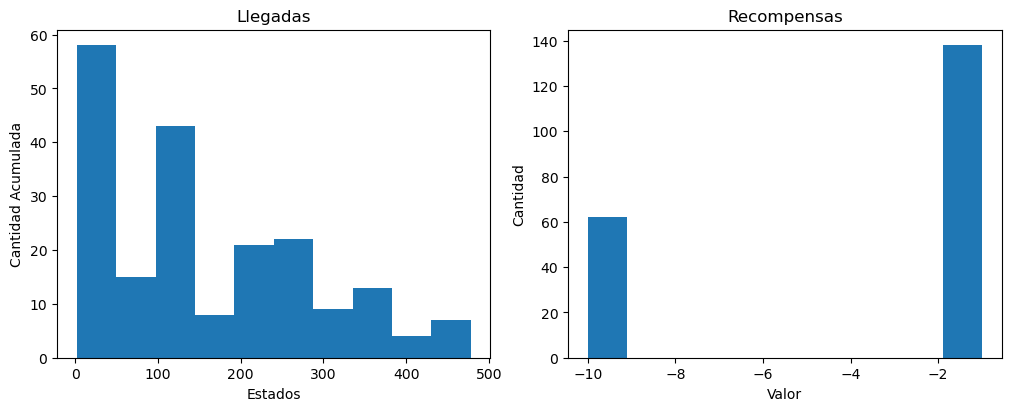

In [11]:
# se cambia el end=terminated por truncated
while not (truncated):
    a = env.action_space.sample()
    obs, reward, terminated, truncated , info = env.step(a)
    s = obs
    r = reward
    a_state.append(s)
    rds.append(r)
    clear_output(wait=True)
    print(f'Termnino={terminated}, truncado={truncated}')
    print(step)
    print(r)
    print(env.render())    
    sleep(.001)
    step += 1
print(f"Terminado en paso: {step}")
out.release()
env.close()
show_tables(a_state,rds)

Una Vista alternativa de los pasos dados de manera aletaroria del taxi con resultados similares sin convergencia

# Usando QLearning

In [12]:
from tqdm.notebook import tqdm

env = gym.make("Taxi-v3",render_mode='ansi')

arrival_state = []
rewards = []
alpha = 0.1
gamma = 0.99
Q = np.zeros(shape=(env.observation_space.n, env.action_space.n))

for episode in tqdm(range(2000)):
    env.reset()
    
    truncated = False    
    while not truncated:  
        s_current = env.unwrapped.s
        
        # Escoger la mejor acción
        a = np.argmax(Q[s_current, :]) 
        
        # Ejecutarla
        #s_future, r, end, info = env.step(a)
        s_future, reward, terminated, truncated , info = env.step(a)
    
        
        # Actualizar Q
        Q[s_current, a] += alpha*(reward + gamma*np.max(Q[s_future, :]) - Q[s_current, a])
    clear_output(wait=True)
    print(f'Episodio en carga: {episode}')
    print(env.render()) 
    sleep(.001)
    rewards.append(reward)
    arrival_state.append(a)
env.close()

Episodio en carga: 1999
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)



## Resultado con Q-Learning para estados convergentes

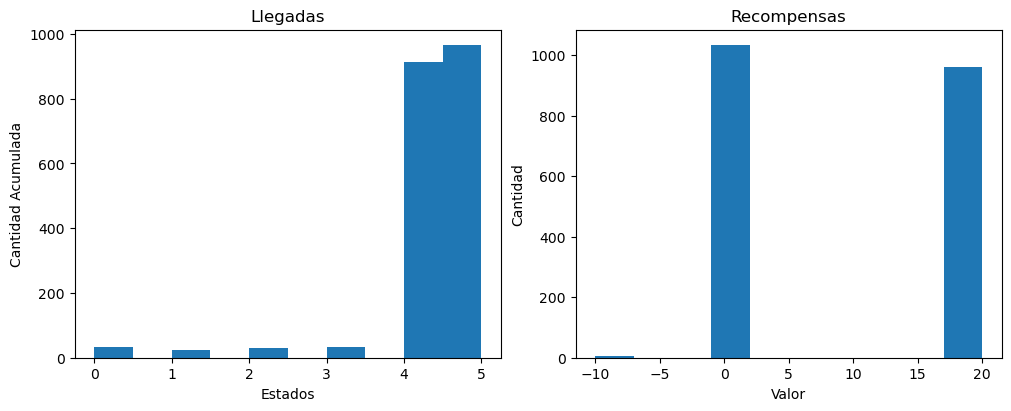

In [13]:
show_tables(arrival_state, rewards)

Basado en los gráfico podemos obtener direccionamientos distintos por sobre los estados anteriores, indicandonos que las acciones del taxi dejan pasajeros efectivamente basándonos en las recompensas obtenidas, y estas son óptimas, pero si considerables para 2000 observaciones, lo que podremos decir ademas que por los datos recurre a la explotación(Condición de optimización profunda en un resultado acotado), cual si es muy efectiva. Además decimos que basados en la cantidad de estados observados, los estados de aprendizaje reducen drásticamente observaciones penalizadas, ya que en el recorrido del taxi busca la mejor ruta cual encontrar pasajeros y los entrega, aún así, nos dice ver si se produce penalización mínima por taxi completo.

In [14]:
display(Q)
from collections import Counter
display(Counter(rewards));

array([[-1.00000000e-01, -1.00000000e-01, -1.00000000e-01,
        -1.00000000e-01,  9.44723618e+02,  0.00000000e+00],
       [-2.25694844e+00, -2.17705327e+00, -2.28951127e+00,
        -2.17705327e+00,  8.62940225e+02, -2.99700100e+00],
       [-1.66787433e+00, -1.68646776e+00, -1.60189313e+00,
        -1.68646776e+00,  9.03529189e+02, -1.99900000e+00],
       ...,
       [-8.96408387e-01, -6.93401708e-01, -8.96408387e-01,
        -8.69667247e-01, -1.00000000e+00, -1.00000000e+00],
       [-1.58805582e+00, -1.57859815e+00, -1.58805582e+00,
        -1.68068411e+00, -1.99900000e+00, -1.99900000e+00],
       [-1.99900000e-01, -1.99900000e-01, -1.99900000e-01,
        -1.90000000e-01, -1.00000000e+00, -1.00000000e+00]])

Counter({-1: 1032, 20: 961, -10: 7})

### Definimos el valor de Epsilon

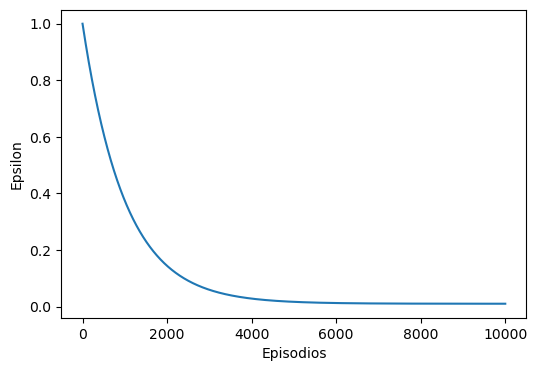

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
episodes = np.arange(10000)
epsilon_init = 1.0
epsilon_end = 0.01
epsilon_rate = 1e-3
ax.plot(episodes, epsilon_end + (epsilon_init - epsilon_end) * np.exp(-epsilon_rate*episodes));
ax.set_xlabel('Episodios')
ax.set_ylabel('Epsilon');

In [16]:
#import matplotlib.pyplot as plt

def update_plot():
    fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True, tight_layout=True)
    for ax_ in ax:
        ax_.cla()
    
    episodes = np.arange((episode+1)//100)*100
    ax[0].errorbar(episodes,
                   np.array(diagnostics['rewards']).mean(axis=1), 
                   np.array(diagnostics['rewards']).std(axis=1));
    ax[0].set_ylabel('Recompensa\npromedio');
    ax[1].errorbar(episodes,
                   np.array(diagnostics['episode_length']).mean(axis=1), 
                   np.array(diagnostics['episode_length']).std(axis=1));
    ax[1].plot(episodes, [195]*len(episodes), 'k--')
    ax[1].set_ylabel('Largo promedio\nde los episodios');
    ax[2].plot(episodes, epsilon(episodes))
    ax[2].set_ylabel('Epsilon')
    ax[2].set_xlabel('Episodios')
    #fig.canvas.draw()
    plt.show()

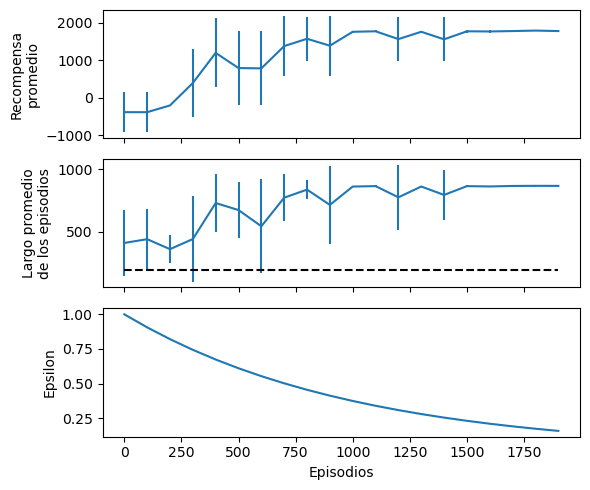

End Process


In [18]:
env = gym.make("Taxi-v3",render_mode='ansi')
Q = np.zeros(shape=(env.observation_space.n, env.action_space.n))

diagnostics = {'rewards': [], 'episode_length': []}
# Parametros
alpha = lambda episode: 0.1
gamma = 0.999
epsilon_init = 1.0 # NUEVO
epsilon_end = 0.01 # NUEVO
epsilon_rate = 1e-3 # NUEVO
epsilon = lambda episode : epsilon_end + (epsilon_init - epsilon_end) * np.exp(-epsilon_rate*episode) # NUEVO

for episode in tqdm(range(2000)):
    env.reset()
    trq = False
    # Entrenamiento
    while not trq:        
        s_current = env.unwrapped.s
        
        # Seleccionar la acción
        if not np.random.binomial(1, p=1.-epsilon(episode)) and ~np.all(Q[s_current]==0): 
            a = np.argmax(Q[s_current])  
        else:
            a = env.action_space.sample() 
        # Ejecutarla
        #s_future, reward, terminated, truncated , info = env.step(a)
        s, r, end,trq, info = env.step(a)
        s_future = s # NUEVO
        # Actualizar Q
        Q[s_current,a] += alpha(episode)*(r + gamma*np.max(Q[s_future]) - Q[s_current][a]) 
       

    # Prueba
    # Cada 100 epocas evaluamos nuestro agente
    if np.mod(episode+1, 100) == 0:
        diagnostics['rewards'].append(np.zeros(shape=(10,)))
        diagnostics['episode_length'].append(np.zeros(shape=(10,)))
        for k in range(10):
            env.reset()    
            trq = False
            episode_length = 0
            episode_reward = 0.0
            while not trq:        
                s_current = env.unwrapped.s
                a = np.argmax(Q[s_current, :])  
                s_future, r, end, trq, info = env.step(a)
                episode_length += a
                episode_reward += r
            diagnostics['rewards'][len(diagnostics['rewards'])-1][k] = episode_reward
            diagnostics['episode_length'][len(diagnostics['episode_length'])-1][k] = episode_length
        clear_output(wait=True)
        update_plot()
print("End Process")
#plt.show()

Basado en los datos anterior mente usando un epsilon 10⁻3, gamma = 0.9 y alpha=0.9 el promedio de recompensas demra en tomar valores convergentes donde se produce exploracion hasta los 2000 episodios, en comparación de solo cambiar el gamma=0.999 la convergencia en los valores de exploracion se reduce a 1500 aprox,donde entregamos mejor preferencia a los espacios de búsqueda en explorar antes de explotar.

basado en la matriz de recompensas, se logra ver q obviamente tenemos los estados iniciales son 0, y que van incrementandose con el tiempo, ahora durante las mejores opciones, en la etapa final de entrenamiento, nos dice que es mejor cuando se mueve al sur, este y oeste, indicando que son las mejores opciones al finalizar el proceso.